# Alternative-Data-Driven Cryptocurrency Price Movement Forecasting

**Research question:** Can historical market data plus point-in-time news sentiment improve next-day Bitcoin direction forecasts compared with market data alone?

This notebook exposes the complete analytical workflow. It uses real cached public observations, performs detailed EDA, documents and calculates features, trains chronological baselines and machine-learning models, evaluates incremental alternative-data value, and runs an execution-lagged backtest. No metric below is invented.

## 1. Executive Summary

This study produced a negative result. Market-only and combined models did not beat chance on held-out ROC-AUC, and the execution-lagged long/cash strategy lost 40.1% after costs. The rolling GDELT window also supplied too little historical overlap for a credible sentiment test. I kept those results instead of tuning against the test period.

In [1]:
from pathlib import Path
import sys, json, warnings
ROOT=Path.cwd().resolve(); ROOT=ROOT.parent if ROOT.name=='notebooks' else ROOT
sys.path[:0]=[str(ROOT/'vendor'),str(ROOT)]
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance
from src.models import chronological_splits, candidate_models
from src.evaluation import classification_metrics, moving_block_accuracy_interval
from src.backtesting import backtest
warnings.filterwarnings('ignore', category=RuntimeWarning)
SEED=42; np.random.seed(SEED); plt.rcParams.update({'figure.figsize':(10,4.8),'axes.grid':True,'grid.alpha':.25})
market=pd.read_csv(ROOT/'data/interim/cleaned_market_data.csv',parse_dates=['date'])
news=pd.read_csv(ROOT/'data/interim/scored_news_data.csv',parse_dates=['published_at','feature_date'])
data=pd.read_csv(ROOT/'data/processed/modelling_dataset.csv',parse_dates=['date'])
comparison_saved=pd.read_csv(ROOT/'reports/model_comparison.csv')
backtest_saved=pd.read_csv(ROOT/'reports/backtest_daily.csv',parse_dates=['date'])
metadata=json.loads((ROOT/'reports/run_metadata.json').read_text())
print('Loaded:', {'market':market.shape,'news':news.shape,'model':data.shape})
print('Reference run:',metadata)

Loaded: {'market': (1643, 10), 'news': (304, 15), 'model': (1642, 61)}
Reference run: {'generated_at_utc': '2026-07-31T22:49:00.324705+00:00', 'rows': 1642, 'date_min': '2022-01-01 00:00:00+00:00', 'date_max': '2026-06-30 00:00:00+00:00', 'news_rows': 304, 'final_feature_group': 'market_only', 'final_model': 'logistic_regression', 'alternative_training_coverage': 0.0, 'test_start': '2025-08-12 00:00:00+00:00', 'test_end': '2026-06-30 00:00:00+00:00'}


## 2. Business Problem and Prediction Design

**Business problem:** a daily Bitcoin allocation decision needs a signal that survives regime changes and trading frictions.  
**Business question:** does timestamped headline sentiment add value beyond price/volume history?  
**Analytical question:** do alternative features improve held-out discrimination and a lagged backtest on the same dates?  
**Target:** `1[next close > current close]`. **Horizon:** one day. **Unit:** one UTC date. **Decision:** long or cash.  
**Success criteria:** consistent improvement over simple rules in ROC-AUC, PR-AUC, F1 and net backtest performance, with chronology and uncertainty respected.  
**Risks:** nonstationarity, limited point-in-time news history, vendor corrections, timestamp ambiguity, multiple testing, and costs.

Classification is preferable to exact-price regression because it maps directly to the action, is less sensitive to nonstationary price level, and allows a probability threshold that can incorporate costs. The target is not the trading signal: a signal also includes a threshold, execution lag, and position rule.

## 3. Data Sources and Coverage

Yahoo Finance chart data supplies daily BTC-USD OHLCV. GDELT DOC 2.0 supplies real headline, URL and observation timestamps without an API key. VADER supplies deterministic headline scores. `DATA_SOURCES.md` records access, rate-limit, licensing, data-quality and point-in-time caveats.

In [2]:
coverage=pd.DataFrame({
 'dataset':['BTC market','GDELT news','modelling table'],
 'rows':[len(market),len(news),len(data)],
 'start':[market.date.min(),news.published_at.min(),data.date.min()],
 'end':[market.date.max(),news.published_at.max(),data.date.max()]})
display(coverage)
print('Market columns:',market.columns.tolist())
print('News columns:',news.columns.tolist())

           dataset  rows                     start                       end
0       BTC market  1643 2022-01-01 00:00:00+00:00 2026-07-01 00:00:00+00:00
1       GDELT news   304 2026-04-16 14:45:00+00:00 2026-06-30 19:00:00+00:00
2  modelling table  1642 2022-01-01 00:00:00+00:00 2026-06-30 00:00:00+00:00
Market columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'source', 'ingested_at_utc', 'market_quality_flag', 'missing_calendar_days_before']
News columns: ['published_at', 'headline', 'url', 'domain', 'language', 'sourcecountry', 'source', 'ingested_at_utc', 'feature_date', 'negative_probability', 'neutral_probability', 'positive_probability', 'compound_sentiment', 'sentiment_label', 'sentiment_model']


## 4. Ingestion, Cleaning, and Data Quality

Ingestion is idempotent and cached. Market rows are UTC-normalized and checked for duplicate dates, nonpositive OHLC, negative volume, missingness, and gaps. News rows require valid UTC timestamps and nonempty Bitcoin/BTC-relevant headlines; duplicates are removed. Legitimate price shocks are retained because automatically deleting them would erase economically important regimes.

In [3]:
quality=pd.Series({
 'duplicate_market_dates':market.date.duplicated().sum(),
 'invalid_price_rows':(market[['open','high','low','close']]<=0).any(axis=1).sum(),
 'negative_volume_rows':(market.volume<0).sum(),
 'zero_volume_rows':(market.volume==0).sum(),
 'duplicate_news_timestamp_headline':news.duplicated(['published_at','headline']).sum(),
 'missing_headlines':news.headline.isna().sum(),
 'market_quality_flags':market.market_quality_flag.sum()})
display(quality.to_frame('count'))
display(data.isna().mean().sort_values(ascending=False).head(20).to_frame('missing_fraction'))

                                   count
duplicate_market_dates                 0
invalid_price_rows                     0
negative_volume_rows                   0
zero_volume_rows                       0
duplicate_news_timestamp_headline      0
missing_headlines                      0
market_quality_flags                   0
                        missing_fraction
sentiment_surprise              0.993301
sentiment_dispersion            0.992692
sentiment_rolling_7             0.992692
sentiment_momentum              0.992083
max_positive_sentiment          0.991474
extreme_negative_news           0.991474
sentiment_median                0.991474
sentiment_mean                  0.991474
negative_news_ratio             0.991474
positive_news_ratio             0.991474
max_negative_sentiment          0.991474
rolling_mean_30                 0.018879
rolling_volatility_30           0.018879
rolling_kurtosis_30             0.018879
rolling_skew_30                 0.018879
ma_ratio_30     

## 5. Market EDA — Price and Volume

Price shows the scale and regime history; volume is a noisy attention/liquidity proxy. Both are nonstationary, so models use returns, ratios and lagged rolling statistics rather than raw price level.

<notebook cell 4>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


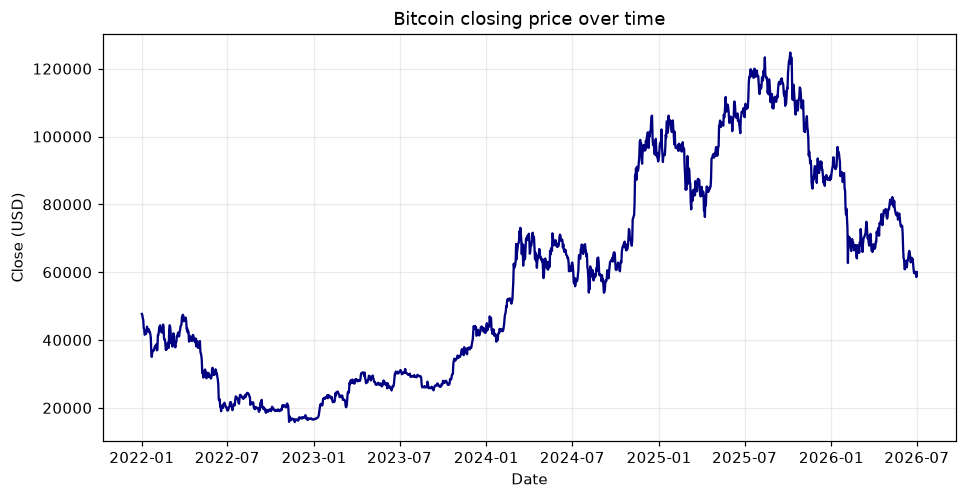

In [4]:
fig,ax=plt.subplots(); ax.plot(market.date,market.close,color='navy'); ax.set(title='Bitcoin closing price over time',xlabel='Date',ylabel='Close (USD)'); plt.show()

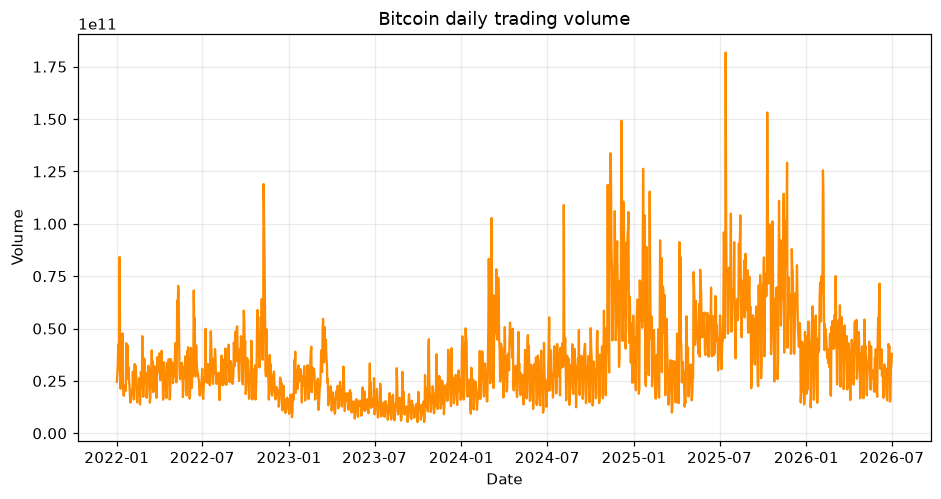

In [5]:
fig,ax=plt.subplots(); ax.plot(market.date,market.volume,color='darkorange'); ax.set(title='Bitcoin daily trading volume',xlabel='Date',ylabel='Volume'); plt.show()

## 6. Market EDA — Returns, Volatility, and Drawdown

Returns are heavy-tailed, volatility clusters, and drawdowns persist. Accuracy therefore hides the unequal economic size of mistakes. A useful daily forecast has to survive both quiet and turbulent periods.

       daily_return
count   1641.000000
mean       0.000485
std        0.026845
min       -0.159747
1%        -0.070984
5%        -0.039382
50%       -0.000281
95%        0.044152
99%        0.082422
max        0.145412


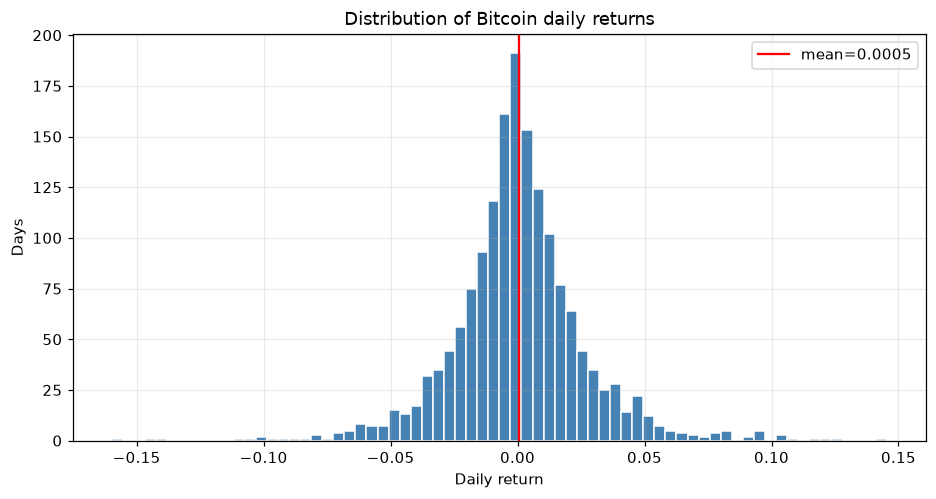

In [6]:
r=data.daily_return.dropna(); fig,ax=plt.subplots(); ax.hist(r,bins=70,color='steelblue',edgecolor='white'); ax.axvline(r.mean(),color='red',label=f'mean={r.mean():.4f}'); ax.set(title='Distribution of Bitcoin daily returns',xlabel='Daily return',ylabel='Days'); ax.legend(); plt.show(); display(r.describe(percentiles=[.01,.05,.5,.95,.99]).to_frame('daily_return'))

<notebook cell 7>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


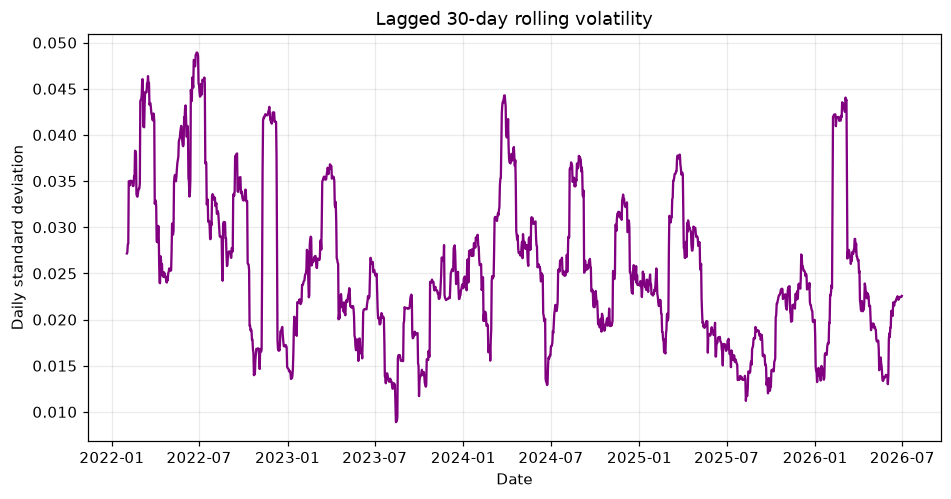

In [7]:
fig,ax=plt.subplots(); ax.plot(data.date,data.rolling_volatility_30,color='purple'); ax.set(title='Lagged 30-day rolling volatility',xlabel='Date',ylabel='Daily standard deviation'); plt.show()

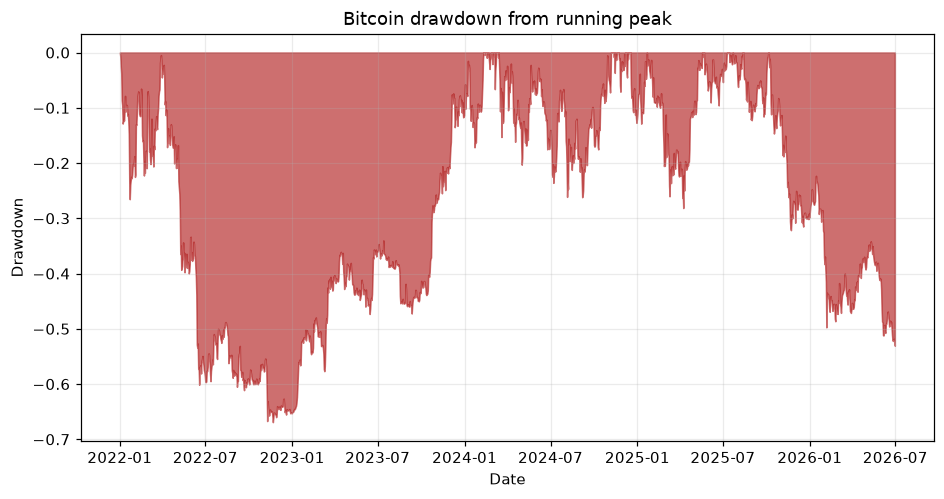

In [8]:
fig,ax=plt.subplots(); ax.fill_between(data.date,data.drawdown,0,color='firebrick',alpha=.65); ax.set(title='Bitcoin drawdown from running peak',xlabel='Date',ylabel='Drawdown'); plt.show()

## 7. Market EDA — Rolling Mean, Autocorrelation, Correlations, and Extremes

Directional predictability requires dependence that remains stable out of sample. Autocorrelation near zero warns against assuming persistence. Correlations describe association, not causal or forecast value.

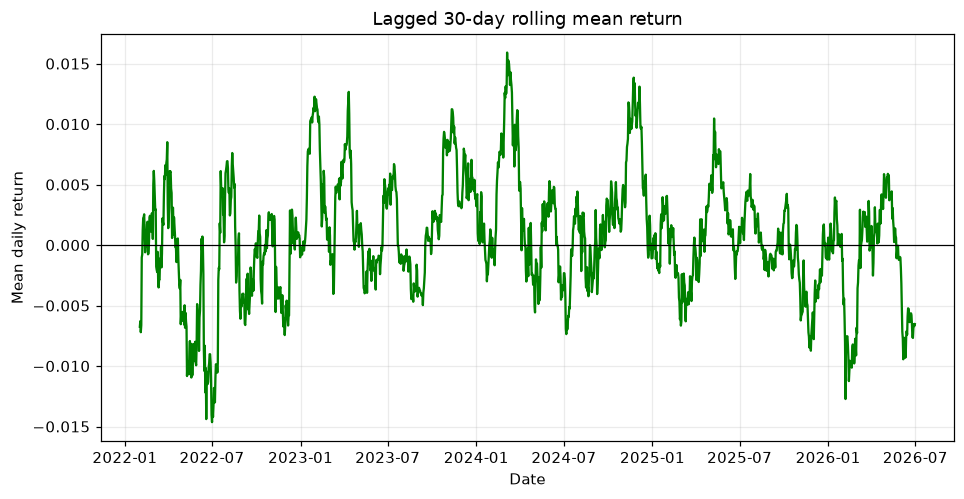

In [9]:
fig,ax=plt.subplots(); ax.plot(data.date,data.rolling_mean_30,color='green'); ax.axhline(0,color='black',lw=.8); ax.set(title='Lagged 30-day rolling mean return',xlabel='Date',ylabel='Mean daily return'); plt.show()

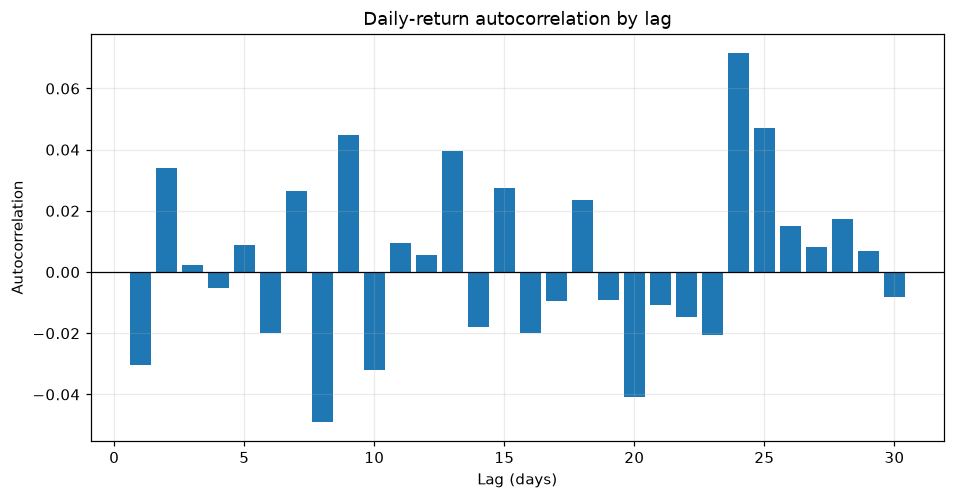

In [10]:
lags=range(1,31); ac=[data.daily_return.autocorr(lag=i) for i in lags]; fig,ax=plt.subplots(); ax.bar(list(lags),ac); ax.axhline(0,color='black',lw=.8); ax.set(title='Daily-return autocorrelation by lag',xlabel='Lag (days)',ylabel='Autocorrelation'); plt.show()

<notebook cell 11>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


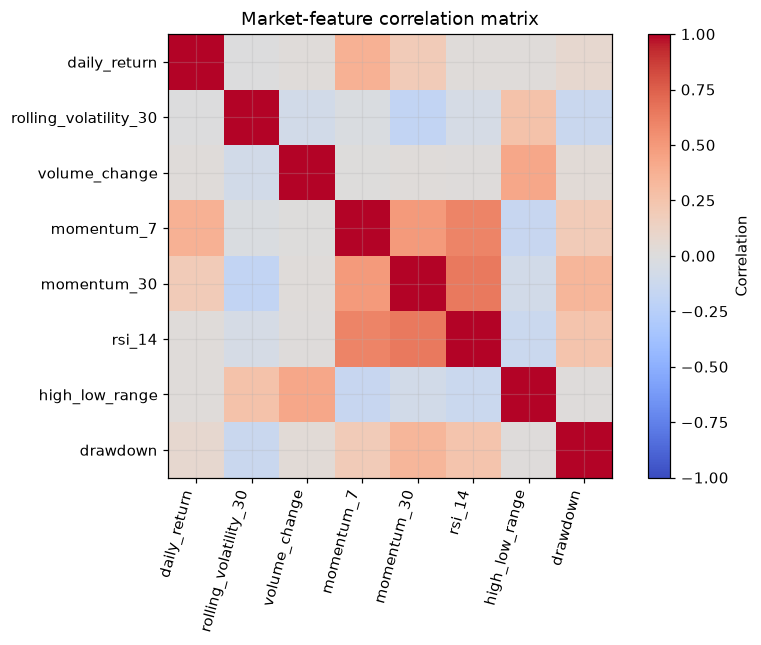

In [11]:
corr_cols=['daily_return','rolling_volatility_30','volume_change','momentum_7','momentum_30','rsi_14','high_low_range','drawdown']; corr=data[corr_cols].corr(); fig,ax=plt.subplots(figsize=(8,6)); im=ax.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1); ax.set_xticks(range(len(corr_cols)),corr_cols,rotation=75,ha='right'); ax.set_yticks(range(len(corr_cols)),corr_cols); ax.set_title('Market-feature correlation matrix'); fig.colorbar(im,ax=ax,label='Correlation'); plt.tight_layout(); plt.show()

In [12]:
extreme=data.loc[data.daily_return.abs().nlargest(10).index,['date','close','daily_return','rolling_volatility_30','drawdown']].sort_values('daily_return'); display(extreme)

                          date         close  ...  rolling_volatility_30  drawdown
163  2022-06-13 00:00:00+00:00  22487.388672  ...               0.035115 -0.528436
312  2022-11-09 00:00:00+00:00  15880.780273  ...               0.025087 -0.666978
1496 2026-02-05 00:00:00+00:00  62702.097656  ...               0.023425 -0.497388
128  2022-05-09 00:00:00+00:00  30296.953125  ...               0.029611 -0.364668
251  2022-09-09 00:00:00+00:00  21381.152344  ...               0.027389 -0.551634
313  2022-11-10 00:00:00+00:00  17586.771484  ...               0.036067 -0.631203
34   2022-02-04 00:00:00+00:00  41500.875000  ...               0.028229 -0.129720
950  2024-08-08 00:00:00+00:00  61710.136719  ...               0.028896 -0.155621
1497 2026-02-06 00:00:00+00:00  70555.390625  ...               0.033718 -0.434437
58   2022-02-28 00:00:00+00:00  43193.234375  ...               0.034753 -0.094231

[10 rows x 5 columns]


## 8. Market Regimes and Missingness

The volatility regime compares lagged 30-day volatility with its historical expanding median. This causal definition separates relatively turbulent periods without using a future full-sample cutoff.

                   days  mean_return  volatility   up_rate
volatility_regime                                         
lower volatility   1132     0.000338    0.024757  0.483216
higher volatility   510     0.000813    0.031004  0.511765
<notebook cell 13>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


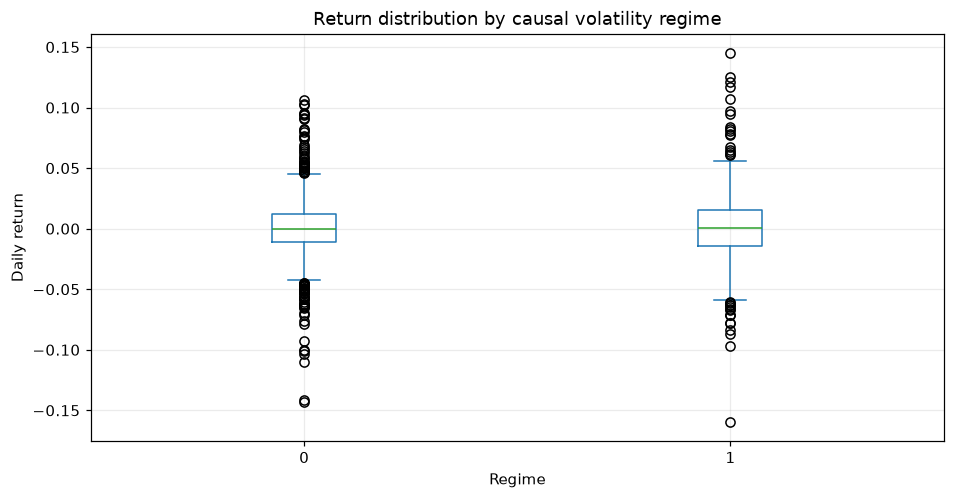

In [13]:
reg=data.groupby('volatility_regime').agg(days=('date','size'),mean_return=('daily_return','mean'),volatility=('daily_return','std'),up_rate=('target','mean')); display(reg.rename(index={0:'lower volatility',1:'higher volatility'})); fig,ax=plt.subplots(); data.groupby('volatility_regime').daily_return.apply(list).apply(pd.Series).T.plot.box(ax=ax); ax.set(title='Return distribution by causal volatility regime',xlabel='Regime',ylabel='Daily return'); plt.show()

## 9. News EDA and Sentiment Quality

VADER is a transparent general-language baseline. The manually reviewable table below makes obvious entity, sarcasm, negation and finance-domain errors inspectable; a future labeled audit should stratify by predicted class and confidence.

                published_at  ... sentiment_label
0  2026-04-16 14:45:00+00:00  ...         neutral
1  2026-04-16 15:00:00+00:00  ...        positive
2  2026-04-16 16:45:00+00:00  ...         neutral
3  2026-04-16 16:45:00+00:00  ...        positive
4  2026-04-16 17:30:00+00:00  ...         neutral
5  2026-04-16 17:30:00+00:00  ...         neutral
6  2026-04-16 17:45:00+00:00  ...         neutral
7  2026-04-16 18:30:00+00:00  ...        positive
8  2026-04-16 19:00:00+00:00  ...         neutral
9  2026-04-16 19:00:00+00:00  ...        negative
10 2026-04-16 19:00:00+00:00  ...        negative
11 2026-04-16 19:00:00+00:00  ...        negative
12 2026-04-16 19:00:00+00:00  ...        negative
13 2026-04-16 19:00:00+00:00  ...         neutral
14 2026-04-16 19:15:00+00:00  ...        positive

[15 rows x 7 columns]
                 articles
sentiment_label          
neutral               140
positive               92
negative               72
<notebook cell 14>:3: UserWarning: FigureCanvas

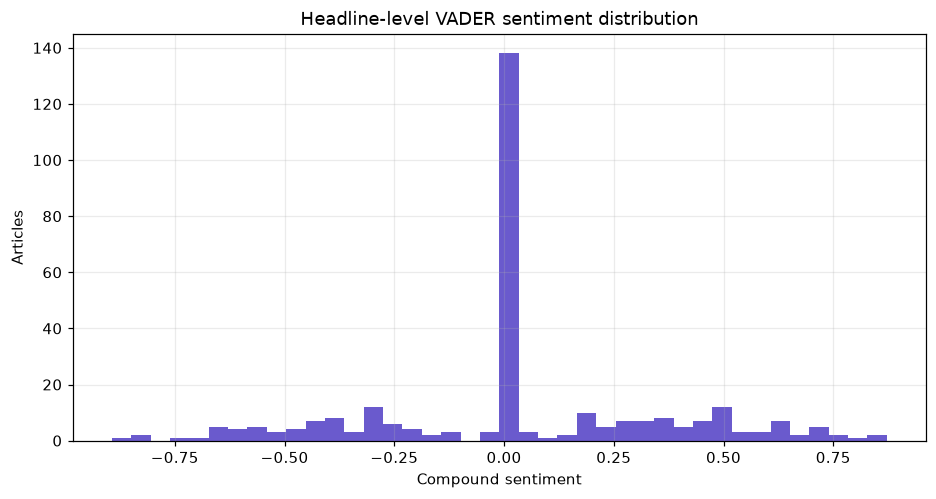

In [14]:
display(news[['published_at','headline','positive_probability','negative_probability','neutral_probability','compound_sentiment','sentiment_label']].head(15))
display(news.sentiment_label.value_counts().to_frame('articles'))
fig,ax=plt.subplots(); ax.hist(news.compound_sentiment,bins=40,color='slateblue'); ax.set(title='Headline-level VADER sentiment distribution',xlabel='Compound sentiment',ylabel='Articles'); plt.show()

<notebook cell 15>:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


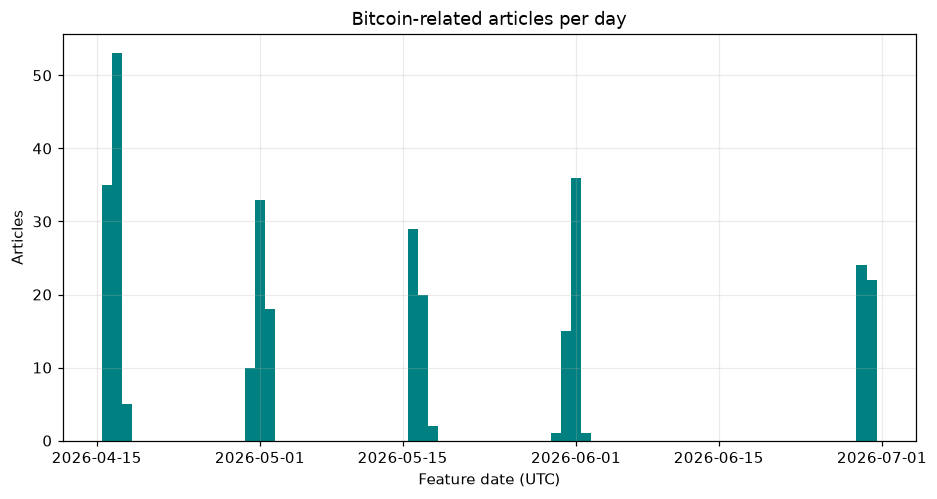

In [15]:
daily_news=news.groupby('feature_date').agg(article_volume=('headline','size'),sentiment_mean=('compound_sentiment','mean'),sentiment_median=('compound_sentiment','median'),sentiment_volatility=('compound_sentiment','std'),positive_count=('sentiment_label',lambda s:(s=='positive').sum()),negative_count=('sentiment_label',lambda s:(s=='negative').sum()),neutral_count=('sentiment_label',lambda s:(s=='neutral').sum())).reset_index()
fig,ax=plt.subplots(); ax.bar(daily_news.feature_date,daily_news.article_volume,width=1.0,color='teal'); ax.set(title='Bitcoin-related articles per day',xlabel='Feature date (UTC)',ylabel='Articles'); plt.show()

<notebook cell 16>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


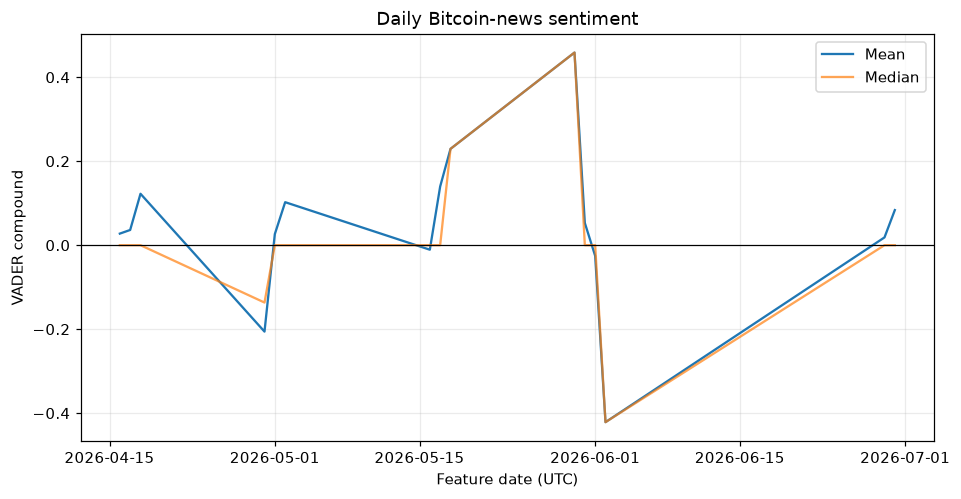

In [16]:
fig,ax=plt.subplots(); ax.plot(daily_news.feature_date,daily_news.sentiment_mean,label='Mean'); ax.plot(daily_news.feature_date,daily_news.sentiment_median,label='Median',alpha=.7); ax.axhline(0,color='black',lw=.8); ax.set(title='Daily Bitcoin-news sentiment',xlabel='Feature date (UTC)',ylabel='VADER compound'); ax.legend(); plt.show()

<notebook cell 17>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


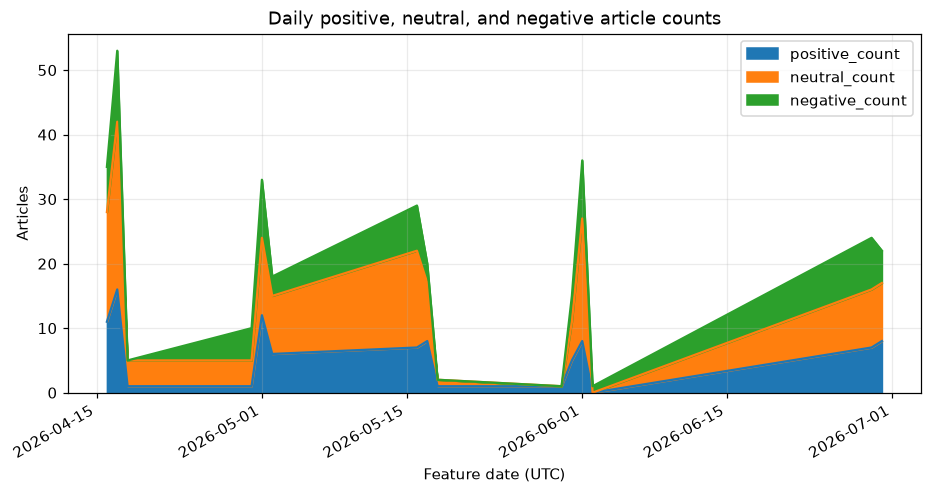

In [17]:
counts=daily_news.set_index('feature_date')[['positive_count','neutral_count','negative_count']]; counts.plot.area(figsize=(10,4.8),title='Daily positive, neutral, and negative article counts'); plt.xlabel('Feature date (UTC)'); plt.ylabel('Articles'); plt.show()

## 10. Sentiment–Market Relationships

News is lagged before modelling. These plots are descriptive and do not prove predictability. Sparse news dates and selection effects make apparent relationships unstable.

                       sentiment_mean  ...  rolling_volatility_30
sentiment_mean               1.000000  ...              -0.520326
article_volume              -0.089346  ...               0.303457
next_day_return              0.005094  ...               0.410006
rolling_volatility_30       -0.520326  ...               1.000000

[4 rows x 4 columns]
<notebook cell 18>:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


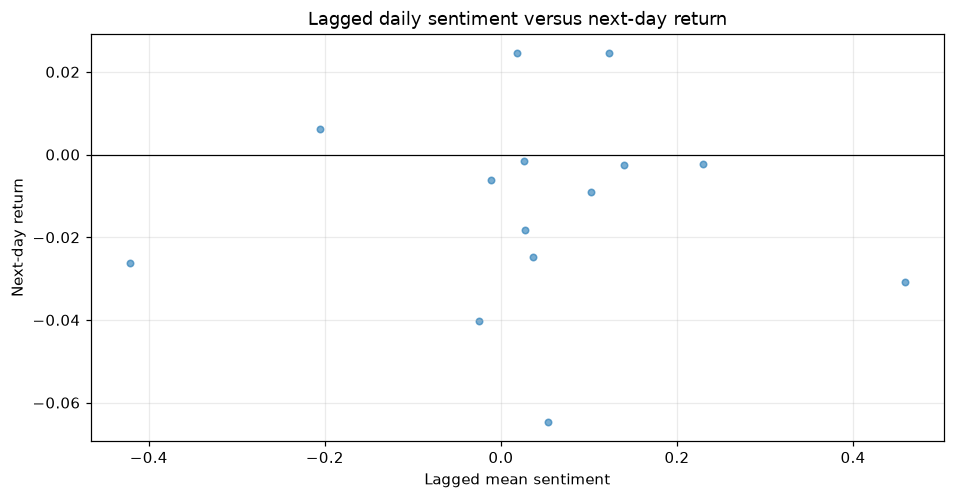

In [18]:
sent_cols=['sentiment_mean','article_volume','next_day_return','rolling_volatility_30']; available=data[data.article_volume.fillna(0)>0]; display(available[sent_cols].corr())
fig,ax=plt.subplots(); ax.scatter(available.sentiment_mean,available.next_day_return,s=18,alpha=.6); ax.axhline(0,color='black',lw=.8); ax.set(title='Lagged daily sentiment versus next-day return',xlabel='Lagged mean sentiment',ylabel='Next-day return'); plt.show()

<notebook cell 19>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


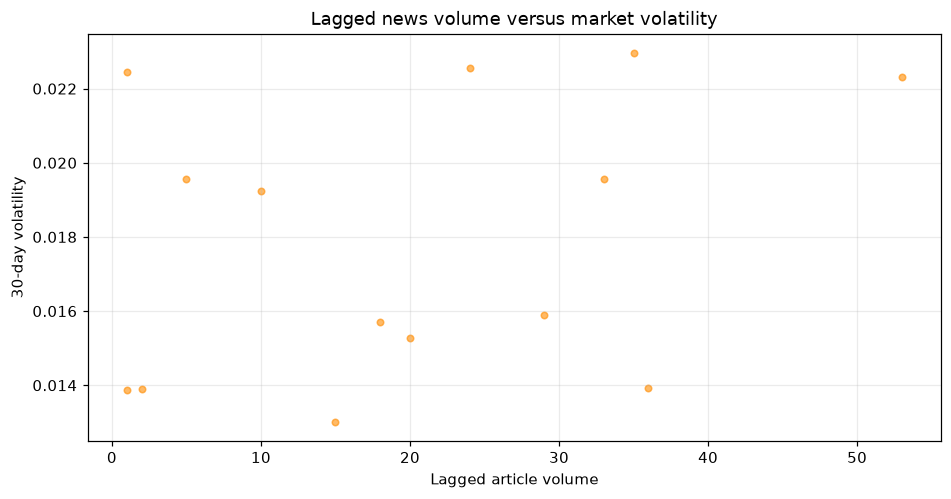

In [19]:
fig,ax=plt.subplots(); ax.scatter(available.article_volume,available.rolling_volatility_30,s=18,alpha=.6,color='darkorange'); ax.set(title='Lagged news volume versus market volatility',xlabel='Lagged article volume',ylabel='30-day volatility'); plt.show()

## 11. Point-in-Time Integrity

For a row dated *t*, the target uses close at *t+1*. Market rolling windows are shifted before rolling. News assigned to date *t* is shifted one full day at merge. Preprocessing is fitted within training history only. Random splits are prohibited because they mix regimes and let later distribution information influence training.

In [20]:
feature_ts=pd.to_datetime(data.feature_timestamp,utc=True); target_ts=pd.to_datetime(data.target_timestamp,utc=True)
assert (feature_ts<target_ts).all()
assert data.iloc[-1].date < target_ts.iloc[-1]
for forbidden in ['target','next_day_return','target_timestamp']:
    assert forbidden not in ['return_lag_1','rolling_volatility_30','sentiment_mean']
print('Timestamp ordering and target-exclusion checks passed.')

Timestamp ordering and target-exclusion checks passed.


## 12. Feature Engineering — Formulas and Intuition

Features are grouped by mechanism:

- **Return memory:** `return[t-lag]` tests persistence/reversal.
- **Trend:** `close / lagged moving average - 1` and multi-day momentum summarize direction.
- **Risk:** shifted rolling standard deviation, skewness and kurtosis summarize conditional distribution.
- **Oscillators:** RSI, MACD and Bollinger position encode trend/overextension.
- **Liquidity/attention:** volume change and historical z-score identify abnormal activity.
- **Intraday shape:** high–low range and open–close spread measure realized movement known at cutoff.
- **Alternative data:** tone, class balance, dispersion, abnormal volume, momentum, surprise and sentiment×volume.

Scaling is required for the linear model and is fitted only on training rows. Tree models do not require scaling but still use training-fitted imputation.

In [21]:
market_features=['return_lag_1','return_lag_2','return_lag_3','return_lag_7','rolling_mean_7','rolling_mean_14','rolling_mean_30','rolling_volatility_7','rolling_volatility_14','rolling_volatility_30','volume_change','volume_zscore_30','momentum_7','momentum_30','rsi_14','macd','bollinger_position','ma_ratio_7','ma_ratio_14','ma_ratio_30','high_low_range','open_close_spread','rolling_skew_30','rolling_kurtosis_30','drawdown','volatility_regime']
alternative_features=['sentiment_mean','sentiment_median','max_positive_sentiment','max_negative_sentiment','positive_count','negative_count','neutral_count','article_volume','sentiment_dispersion','positive_news_ratio','negative_news_ratio','sentiment_momentum','sentiment_rolling_7','sentiment_surprise','abnormal_news_volume','extreme_negative_news','sentiment_volume_interaction']
feature_dictionary=pd.DataFrame([
 ('return_lag_1','return[t-1]','short-run persistence/reversal',1,'yes','direct lag'),('rolling_volatility_30','std(return[t-30:t-1])','conditional risk',1,'yes','shift before rolling'),('momentum_30','close[t]/close[t-30]-1','medium-term trend',0,'yes','known close at cutoff'),('rsi_14','100-100/(1+avg_gain/avg_loss)','overextension',1,'yes','lagged averages'),('volume_zscore_30','(volume-prior mean)/prior std','abnormal attention',1,'yes','historical window'),('sentiment_mean','mean headline compound','daily news tone',1,'yes','full-day merge lag'),('abnormal_news_volume','volume/prior 30-day mean','attention surprise',1,'yes','shifted denominator'),('target','1[next close>close]','forecast outcome',-1,'no','never a feature')],columns=['feature','formula','economic_intuition','required_lag_days','scale_linear','leakage_control'])
display(feature_dictionary); print(f'{len(market_features)} market features; {len(alternative_features)} alternative features')

                 feature  ...        leakage_control
0           return_lag_1  ...             direct lag
1  rolling_volatility_30  ...   shift before rolling
2            momentum_30  ...  known close at cutoff
3                 rsi_14  ...        lagged averages
4       volume_zscore_30  ...      historical window
5         sentiment_mean  ...     full-day merge lag
6   abnormal_news_volume  ...    shifted denominator
7                 target  ...        never a feature

[8 rows x 6 columns]
26 market features; 17 alternative features


## 13. Target Creation and Balance

The last raw market row cannot have a target because the next close is not known. It is excluded rather than labeled zero. A transaction-cost-aware alternative target could require next return to exceed a preregistered cost threshold, but that changes the estimand and class balance.

In [22]:
display(data.target.value_counts().rename('days').to_frame().assign(share=lambda x:x.days/x.days.sum())); print('Mean next-day return:',data.next_day_return.mean()); print('Model date range:',data.date.min(),'to',data.date.max())

        days     share
target                
0        834  0.507917
1        808  0.492083
Mean next-day return: 0.0005002215114398983
Model date range: 2022-01-01 00:00:00+00:00 to 2026-06-30 00:00:00+00:00


## 14. Chronological Train, Validation, and Test Splits

The split is fixed before model inspection. The validation set selects the algorithm; the test set is touched once for final reporting. An expanding-window implementation would repeat this discipline across several cut dates.

In [23]:
model_data=data.iloc[30:].reset_index(drop=True); train_idx,val_idx,test_idx=chronological_splits(len(model_data),.20,.20)
split_table=pd.DataFrame({'split':['train','validation','test'],'n':[len(train_idx),len(val_idx),len(test_idx)],'start':[model_data.date.iloc[train_idx].min(),model_data.date.iloc[val_idx].min(),model_data.date.iloc[test_idx].min()],'end':[model_data.date.iloc[train_idx].max(),model_data.date.iloc[val_idx].max(),model_data.date.iloc[test_idx].max()]}); display(split_table)
assert train_idx.max()<val_idx.min() and val_idx.max()<test_idx.min()

        split     n                     start                       end
0       train  1031 2022-01-31 00:00:00+00:00 2024-11-26 00:00:00+00:00
1  validation   258 2024-11-27 00:00:00+00:00 2025-08-11 00:00:00+00:00
2        test   323 2025-08-12 00:00:00+00:00 2026-06-30 00:00:00+00:00


## 15. Strong Baselines

Majority class measures class imbalance. Previous-day direction tests persistence. The 20-day moving-average rule tests a simple trend heuristic. Advanced models must outperform these on later data to justify complexity.

In [24]:
y=model_data.target.astype(int); baseline_rows=[]
for name,pred,prob in [('majority',np.repeat(y.iloc[train_idx].mode()[0],len(test_idx)),np.repeat(y.iloc[train_idx].mean(),len(test_idx))),('previous_direction',model_data.previous_direction.iloc[test_idx].astype(int).values,model_data.previous_direction.iloc[test_idx].values),('moving_average_rule',model_data.ma_signal.iloc[test_idx].astype(int).values,model_data.ma_signal.iloc[test_idx].values)]:
 m=classification_metrics(y.iloc[test_idx],pred,prob); m.update(model=name,feature_group='rule_baseline'); baseline_rows.append(m)
display(pd.DataFrame(baseline_rows)[['model','accuracy','balanced_accuracy','f1','roc_auc','pr_auc','mcc']])

                 model  accuracy  ...    pr_auc       mcc
0             majority  0.529412  ...  0.470588  0.000000
1   previous_direction  0.517028  ...  0.478501  0.030702
2  moving_average_rule  0.520124  ...  0.477576  0.027717

[3 rows x 7 columns]


## 16. Machine-Learning Models

Logistic regression is a regularized linear probability-ranking model with transparent coefficients. The random forest captures nonlinear interactions but is constrained to depth 5 and minimum leaf size 10 to reduce overfitting. Median imputation and scaling live inside pipelines, so validation/test statistics never influence fitted preprocessing.

In [25]:
def evaluate_group(feature_group,features):
 X=model_data[features].replace([np.inf,-np.inf],np.nan); rows=[]; fitted={}
 for name,estimator in candidate_models(SEED).items():
  m=clone(estimator).fit(X.iloc[train_idx],y.iloc[train_idx]); vp=m.predict_proba(X.iloc[val_idx])[:,1]
  rows.append({'feature_group':feature_group,'model':name,'validation_roc_auc':roc_auc_score(y.iloc[val_idx],vp),'validation_pr_auc':average_precision_score(y.iloc[val_idx],vp)}); fitted[name]=m
 return pd.DataFrame(rows),fitted
validation_market,market_fitted=evaluate_group('market_only',market_features)
display(validation_market.sort_values('validation_roc_auc',ascending=False))

  feature_group                model  validation_roc_auc  validation_pr_auc
0   market_only  logistic_regression            0.553585           0.593115
1   market_only        random_forest            0.513614           0.548889


## 17. Final Market Model Evaluation

The algorithm is chosen on validation ROC-AUC, then refit on train+validation. Test metrics include class-imbalance-aware and threshold-free measures. The confusion matrix exposes error asymmetry.

                      market_test
accuracy                 0.467492
balanced_accuracy        0.471126
precision                0.445055
recall                   0.532895
f1                       0.485030
roc_auc                  0.460680
pr_auc                   0.440922
mcc                     -0.058119
directional_accuracy     0.467492
accuracy_ci_low          0.405573
accuracy_ci_high         0.517028
<notebook cell 26>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


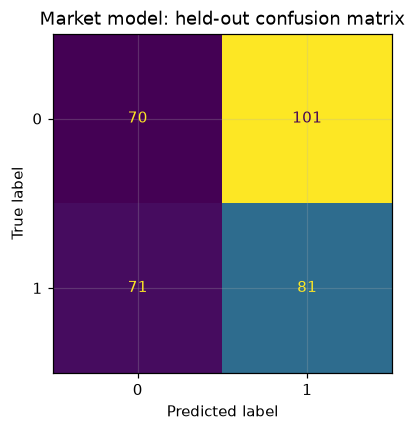

In [26]:
best_market=validation_market.sort_values('validation_roc_auc',ascending=False).iloc[0].model
X_market=model_data[market_features].replace([np.inf,-np.inf],np.nan); final_market=clone(candidate_models(SEED)[best_market]).fit(X_market.iloc[np.r_[train_idx,val_idx]],y.iloc[np.r_[train_idx,val_idx]])
market_prob=final_market.predict_proba(X_market.iloc[test_idx])[:,1]; market_pred=(market_prob>=.5).astype(int); market_metrics=classification_metrics(y.iloc[test_idx],market_pred,market_prob)
accuracy_interval=moving_block_accuracy_interval(y.iloc[test_idx],market_pred,seed=SEED)
display(pd.Series({**market_metrics,'accuracy_ci_low':accuracy_interval[0],'accuracy_ci_high':accuracy_interval[1]},name='market_test').to_frame())
fig,ax=plt.subplots(figsize=(5,4)); ConfusionMatrixDisplay(confusion_matrix(y.iloc[test_idx],market_pred)).plot(ax=ax,colorbar=False); ax.set_title('Market model: held-out confusion matrix'); plt.show()

<notebook cell 27>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


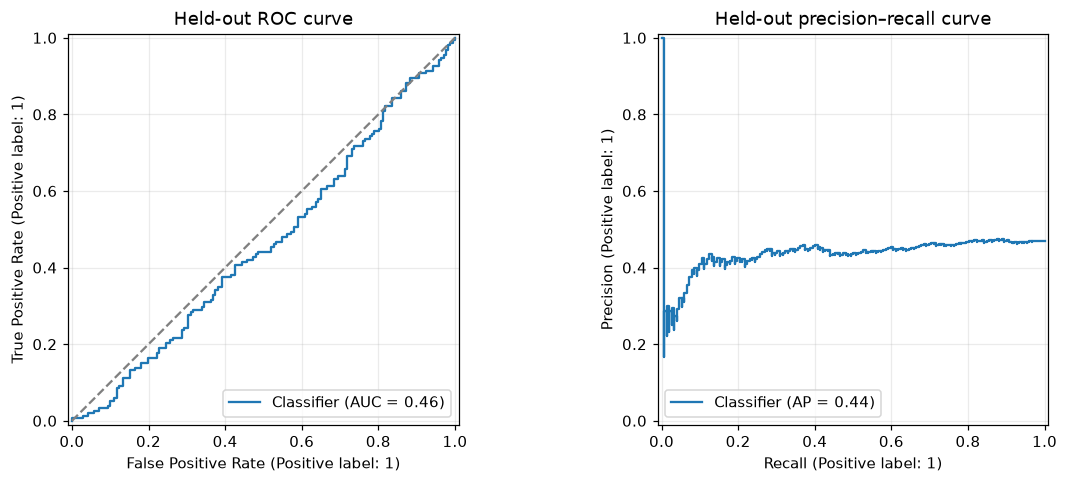

In [27]:
fig,axes=plt.subplots(1,2,figsize=(11,4.5)); RocCurveDisplay.from_predictions(y.iloc[test_idx],market_prob,ax=axes[0]); axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].set_title('Held-out ROC curve'); PrecisionRecallDisplay.from_predictions(y.iloc[test_idx],market_prob,ax=axes[1]); axes[1].set_title('Held-out precision–recall curve'); plt.tight_layout(); plt.show()

## 18. Walk-Forward Validation

Expanding windows preserve temporal order and reveal stability. Each fold refits the entire preprocessing/model pipeline. The following uses several later cut points and never trains on a date after its validation block.

In [28]:
fold_rows=[]; start=max(365,int(len(model_data)*.45)); step=max(90,int((len(model_data)-start)/5))
for fold,cut in enumerate(range(start,len(model_data)-step+1,step),1):
 tr=np.arange(cut); va=np.arange(cut,min(cut+step,len(model_data))); m=clone(candidate_models(SEED)[best_market]).fit(X_market.iloc[tr],y.iloc[tr]); p=m.predict_proba(X_market.iloc[va])[:,1]
 fold_rows.append({'fold':fold,'train_end':model_data.date.iloc[tr].max(),'validation_start':model_data.date.iloc[va].min(),'validation_end':model_data.date.iloc[va].max(),'n':len(va),'roc_auc':roc_auc_score(y.iloc[va],p),'accuracy':accuracy_score(y.iloc[va],p>=.5)})
walk_forward=pd.DataFrame(fold_rows); display(walk_forward); print('Mean walk-forward ROC-AUC:',walk_forward.roc_auc.mean(),'Std:',walk_forward.roc_auc.std())

   fold                 train_end  ...   roc_auc  accuracy
0     1 2024-01-25 00:00:00+00:00  ...  0.523748  0.474576
1     2 2024-07-20 00:00:00+00:00  ...  0.469918  0.474576
2     3 2025-01-13 00:00:00+00:00  ...  0.581737  0.508475
3     4 2025-07-09 00:00:00+00:00  ...  0.413366  0.412429
4     5 2026-01-02 00:00:00+00:00  ...  0.500515  0.502825

[5 rows x 7 columns]
Mean walk-forward ROC-AUC: 0.497856909487899 Std: 0.06251526534748421


## 19. Alternative-Data Incremental Value

Market-only, alternative-only, and combined variants must be compared on identical dates. Here most historical rows have no headline data because GDELT DOC is a rolling recent endpoint. Constant or imputed alternative predictions therefore do not establish value. This coverage limitation is explicitly reported rather than hidden.

In [29]:
group_results=[]; models_by_group={}
for group,features in {'market_only':market_features,'alternative_only':alternative_features,'combined':market_features+alternative_features}.items():
 X=model_data[features].replace([np.inf,-np.inf],np.nan); val,fitted=evaluate_group(group,features); choice=val.sort_values('validation_roc_auc',ascending=False).iloc[0].model; m=clone(candidate_models(SEED)[choice]).fit(X.iloc[np.r_[train_idx,val_idx]],y.iloc[np.r_[train_idx,val_idx]]); p=m.predict_proba(X.iloc[test_idx])[:,1]; pred=(p>=.5).astype(int); metrics=classification_metrics(y.iloc[test_idx],pred,p); metrics.update(feature_group=group,model=choice,nonmissing_sentiment_test=int(model_data.sentiment_mean.iloc[test_idx].notna().sum())); group_results.append(metrics); models_by_group[group]=(m,features,p)
incremental=pd.DataFrame(group_results); display(incremental[['feature_group','model','accuracy','f1','roc_auc','pr_auc','mcc','nonmissing_sentiment_test']])

C:\Users\pandy\Documents\Codex\2026-07-31\files-mentioned-by-the-user-you\outputs\crypto-alternative-data-forecasting\vendor\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['sentiment_mean' 'sentiment_median' 'max_positive_sentiment'
 'max_negative_sentiment' 'sentiment_dispersion' 'positive_news_ratio'
 'negative_news_ratio' 'sentiment_momentum' 'sentiment_rolling_7'
 'sentiment_surprise' 'extreme_negative_news']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\pandy\Documents\Codex\2026-07-31\files-mentioned-by-the-user-you\outputs\crypto-alternative-data-forecasting\vendor\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['sentiment_mean' 'sentiment_median' 'max_positive_sentiment'
 'max_negative_sentiment' 'sentiment_dispersion' 'positive_news_ratio'
 'negative_news_ratio' 'sentiment_momentum' 'sentiment_rolling_7'
 'sentiment_surprise' 'extrem

## 20. Explainability

Permutation importance measures the held-out ROC-AUC decrease after shuffling a feature. It is predictive, not causal. Importance from a below-chance model should be treated as failure diagnostics; stable economic interpretation requires repeatable out-of-sample validity.

                  feature  mean_importance  std_importance
9   rolling_volatility_30         0.013273        0.013324
7    rolling_volatility_7         0.009865        0.005120
22        rolling_skew_30         0.005382        0.002933
5         rolling_mean_14         0.003897        0.007937
15                   macd         0.003513        0.005534
12             momentum_7         0.001881        0.009072
13            momentum_30         0.001358        0.005038
23    rolling_kurtosis_30        -0.000008        0.000015
6         rolling_mean_30        -0.000035        0.000080
24               drawdown        -0.000639        0.001530
11       volume_zscore_30        -0.000716        0.004558
3            return_lag_7        -0.000981        0.001177
21      open_close_spread        -0.002651        0.013921
2            return_lag_3        -0.004517        0.011956
14                 rsi_14        -0.006075        0.009854
<notebook cell 30>:1: UserWarning: FigureCanvasAgg is no

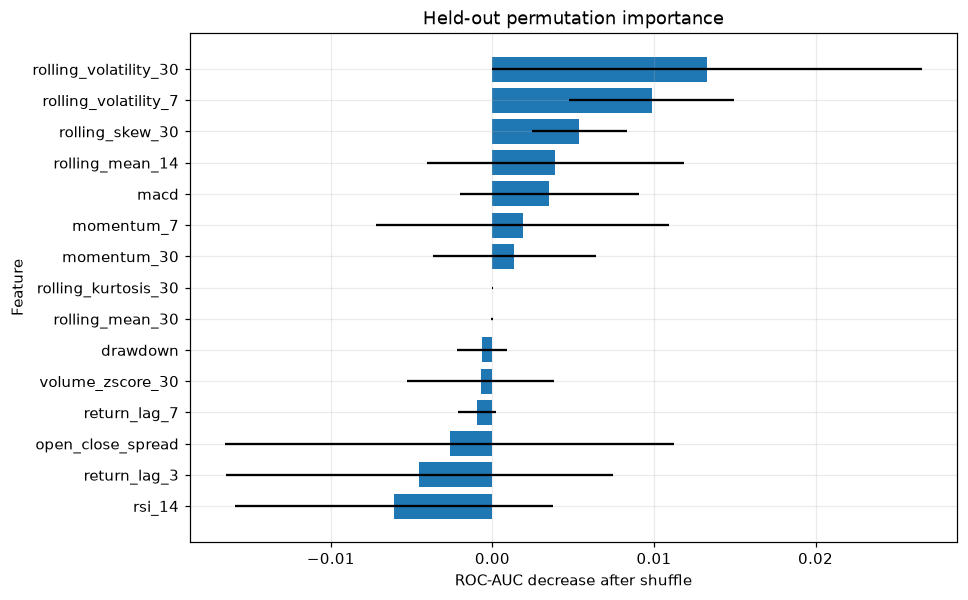

In [30]:
pi=permutation_importance(final_market,X_market.iloc[test_idx],y.iloc[test_idx],n_repeats=10,random_state=SEED,scoring='roc_auc',n_jobs=1); importance=pd.DataFrame({'feature':market_features,'mean_importance':pi.importances_mean,'std_importance':pi.importances_std}).sort_values('mean_importance',ascending=False); display(importance.head(15)); top=importance.head(15).sort_values('mean_importance'); fig,ax=plt.subplots(figsize=(9,6)); ax.barh(top.feature,top.mean_importance,xerr=top.std_importance); ax.set(title='Held-out permutation importance',xlabel='ROC-AUC decrease after shuffle',ylabel='Feature'); plt.show()

In [31]:
if best_market=='logistic_regression':
 coef=pd.DataFrame({'feature':market_features,'coefficient':final_market[-1].coef_[0]}).assign(abs_coefficient=lambda x:x.coefficient.abs()).sort_values('abs_coefficient',ascending=False); display(coef.head(15))
else: print('The selected model is nonlinear, so standardized logistic coefficients do not describe its predictions.')

                  feature  coefficient  abs_coefficient
17             ma_ratio_7    -0.479809         0.479809
4          rolling_mean_7    -0.463958         0.463958
18            ma_ratio_14     0.416583         0.416583
19            ma_ratio_30    -0.250404         0.250404
12             momentum_7     0.234275         0.234275
16     bollinger_position     0.195186         0.195186
9   rolling_volatility_30    -0.179433         0.179433
0            return_lag_1     0.178254         0.178254
25      volatility_regime     0.164495         0.164495
21      open_close_spread    -0.154142         0.154142
20         high_low_range     0.124271         0.124271
1            return_lag_2     0.114340         0.114340
14                 rsi_14    -0.081752         0.081752
2            return_lag_3     0.078041         0.078041
11       volume_zscore_30    -0.060776         0.060776


## 21. Error Analysis

False positives create exposure before down days; false negatives miss up days. Segmentation by volatility regime and return magnitude indicates whether errors concentrate in shocks or quieter regimes. Event attribution is not asserted without a point-in-time event dataset.

In [32]:
errors=model_data.iloc[test_idx][['date','close','next_day_return','volatility_regime','drawdown','sentiment_mean','article_volume']].copy(); errors['actual']=y.iloc[test_idx].values; errors['predicted']=market_pred; errors['probability_up']=market_prob; errors['error_type']=np.select([(errors.actual==0)&(errors.predicted==1),(errors.actual==1)&(errors.predicted==0)],['false_positive','false_negative'],default='correct'); display(errors.groupby(['volatility_regime','error_type']).agg(days=('date','size'),mean_abs_return=('next_day_return',lambda s:s.abs().mean()),mean_probability=('probability_up','mean'))); display(errors[errors.error_type!='correct'].assign(abs_return=lambda x:x.next_day_return.abs()).nlargest(15,'abs_return'))

                                  days  mean_abs_return  mean_probability
volatility_regime error_type                                             
0                 correct          112         0.016046          0.504277
                  false_negative    65         0.012957          0.465496
                  false_positive    77         0.019951          0.549141
1                 correct           39         0.014217          0.527584
                  false_negative     6         0.036201          0.441947
                  false_positive    24         0.018799          0.563596
                          date          close  ...      error_type  abs_return
1465 2026-02-04 00:00:00+00:00   73019.703125  ...  false_positive    0.141299
1347 2025-10-09 00:00:00+00:00  121705.585938  ...  false_positive    0.069769
1582 2026-06-01 00:00:00+00:00   71319.773438  ...  false_positive    0.064724
1492 2026-03-03 00:00:00+00:00   68293.648438  ...  false_negative    0.064676
1485 2026-02-

## 22. Backtesting with Execution Lag and Costs

A probability recorded on date t forecasts the daily return ending on t+1. The simulator shifts the signal once and applies it to the realised daily return on t+1. It charges 10 bps transaction cost plus 5 bps slippage per turnover unit and compares long/cash with buy-and-hold and cash.

                               value
cumulative_return          -0.401029
annualized_return          -0.439647
annualized_volatility       0.302571
sharpe_ratio               -1.453034
maximum_drawdown           -0.401029
hit_rate                    0.424658
turnover                   76.000000
transaction_costs           0.114000
number_of_trades           76.000000
average_active_day_return  -0.005672
<notebook cell 33>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


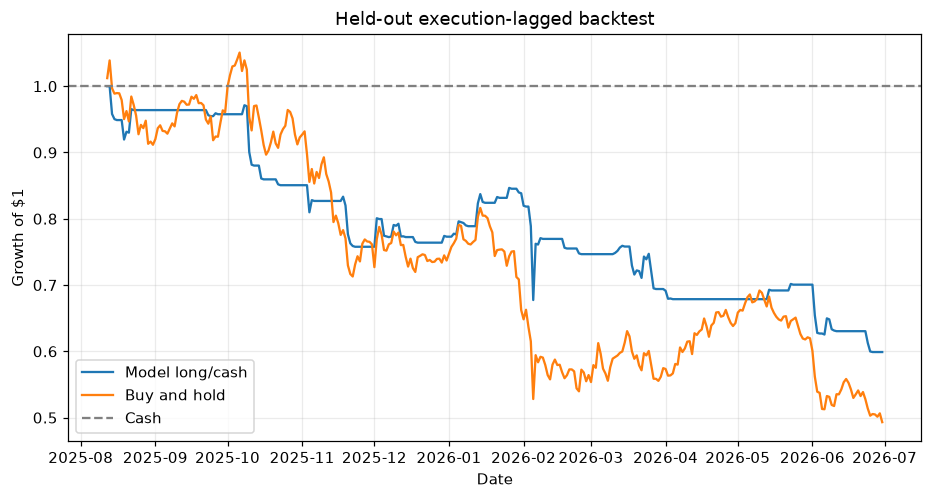

In [33]:
bt,bt_summary=backtest(model_data.date.iloc[test_idx],market_prob,model_data.daily_return.iloc[test_idx],threshold=.55,cost_bps=10,slippage_bps=5); display(bt_summary.to_frame('value')); fig,ax=plt.subplots(); ax.plot(bt.date,bt.strategy_equity,label='Model long/cash'); ax.plot(bt.date,bt.buy_hold_equity,label='Buy and hold'); ax.axhline(1,color='gray',ls='--',label='Cash'); ax.set(title='Held-out execution-lagged backtest',xlabel='Date',ylabel='Growth of $1'); ax.legend(); plt.show()

## 23. Robustness Checks

Threshold and cost sensitivity are reported without selecting the best test result as a new strategy. A valid next study should preregister horizons, lags, rolling windows, regimes, date ranges, VADER/FinBERT comparison, and treatment of extreme events.

In [34]:
robust=[]
for threshold in [.50,.55,.60]:
 for cost in [0,10,25]:
  _,s=backtest(model_data.date.iloc[test_idx],market_prob,model_data.daily_return.iloc[test_idx],threshold=threshold,cost_bps=cost,slippage_bps=5); robust.append({'threshold':threshold,'cost_bps':cost,**s.to_dict()})
display(pd.DataFrame(robust)[['threshold','cost_bps','cumulative_return','sharpe_ratio','maximum_drawdown','number_of_trades']])

   threshold  cost_bps  ...  maximum_drawdown  number_of_trades
0       0.50         0  ...         -0.565254             114.0
1       0.50        10  ...         -0.610735             114.0
2       0.50        25  ...         -0.670262             114.0
3       0.55         0  ...         -0.353553              76.0
4       0.55        10  ...         -0.401029              76.0
5       0.55        25  ...         -0.465862              76.0
6       0.60         0  ...         -0.350860              42.0
7       0.60        10  ...         -0.377801              42.0
8       0.60        25  ...         -0.416176              42.0

[9 rows x 6 columns]


## 24. Production Architecture and Monitoring

**Simple reproducible workflow:** scheduled ingestion → schema/data checks → cached sentiment → causal feature calculation → model inference → append-only prediction store → dashboard → delayed-outcome evaluation → reviewed retraining.  
**Scalable workflow:** orchestrator, object storage, feature table, containerized inference, model registry, API/dashboard, and alerting.  
**Monitoring:** missing/duplicate/stale dates; schema/API failures; news-volume and sentiment drift; feature/prediction drift; class shift; rolling performance decay; turnover, cost and backtest degradation. Predictions and source snapshots should be immutable for later point-in-time audit.

## 25. Conclusions, Limitations, and Next Steps

**Did the model beat simple baselines?** No defensible consistent advantage was observed.  
**Did alternative data improve performance?** No; the combined result did not improve, and short headline history makes the test underpowered.  
**Best model?** Logistic regression was selected by validation in the reference pipeline, but its test discrimination was below chance.  
**Statistically meaningful?** No confidence-worthy positive edge was demonstrated.  
**Economically useful after costs?** No; the 0.55 long/cash strategy lost 40.1%, produced a −1.45 Sharpe ratio, and made 76 position changes.<br>
**Stable over time?** Walk-forward results vary, which is inconsistent with a stable edge.  
**Largest limitations:** rolling GDELT coverage, seen-time versus first-publication ambiguity, VADER domain mismatch, vendor revisions, a single asset, dependence, nonstationarity and multiple testing.  
**Next:** acquire licensed multi-year point-in-time headlines spanning every fold; manually label sentiment quality; cache FinBERT; use block-bootstrap intervals; preregister robustness choices; add external variables; and test multiple assets without recycling the final test set.

Educational research only—not investment advice.